In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

c:\Users\avera\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 42.6M/42.6M [00:03<00:00, 12.9MB/s]

Extracting files...


Path to dataset files: C:\Users\avera\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [3]:
import pandas as pd

In [92]:
customers = pd.read_csv(path + "/olist_customers_dataset.csv")
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
geolo = pd.read_csv(path + "/olist_geolocation_dataset.csv")
geolo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [69]:
items = pd.read_csv(f"{path}\olist_order_items_dataset.csv")
payments = pd.read_csv(f"{path}\olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{path}\olist_order_reviews_dataset.csv")
orders = pd.read_csv(f"{path}\olist_orders_dataset.csv")
products = pd.read_csv(f"{path}\olist_products_dataset.csv")
sellers = pd.read_csv(f"{path}\olist_sellers_dataset.csv")
translation = pd.read_csv(f"{path}\product_category_name_translation.csv")

<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:2: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:2: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\p'
C:\Users\avera\AppData\Local\Temp\ipykernel_19844\361959971.py:1: SyntaxWarning: invalid escape sequence '\o'
  items = pd.read_csv(f"{path}\olist_order_items_dataset.csv")
C:\Users\avera\AppData\Local\Temp\ipykernel_19844\361959971.py:2: SyntaxWarning: invalid escape sequence '\o'
  payments = pd.r

In [72]:
products.dropna(inplace=True)
products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32340 non-null  object 
 1   product_category_name       32340 non-null  object 
 2   product_name_lenght         32340 non-null  float64
 3   product_description_lenght  32340 non-null  float64
 4   product_photos_qty          32340 non-null  float64
 5   product_weight_g            32340 non-null  float64
 6   product_length_cm           32340 non-null  float64
 7   product_height_cm           32340 non-null  float64
 8   product_width_cm            32340 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


In [51]:
order_item = items.merge(orders, on='order_id', how='inner')
order_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   customer_id                    112650 non-null  object 
 8   order_status                   112650 non-null  object 
 9   order_purchase_timestamp       112650 non-null  object 
 10  order_approved_at              112635 non-null  object 
 11  order_delivered_carrier_date   111456 non-null  object 
 12  order_delivered_customer_date 

In [64]:
order_item.groupby('order_status').size()

order_status
approved            3
canceled          542
delivered      110197
invoiced          359
processing        357
shipped          1185
unavailable         7
dtype: int64

In [66]:
product_item_order = order_item.merge(products, on='product_id', how='left')
product_item_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   customer_id                    112650 non-null  object 
 8   order_status                   112650 non-null  object 
 9   order_purchase_timestamp       112650 non-null  object 
 10  order_approved_at              112635 non-null  object 
 11  order_delivered_carrier_date   111456 non-null  object 
 12  order_delivered_customer_date 

In [97]:
product_null = product_item_order.loc[product_item_order['product_category_name'].isnull()]

In [99]:
product_cus = product_null.merge(customers, on='customer_id', how='left')

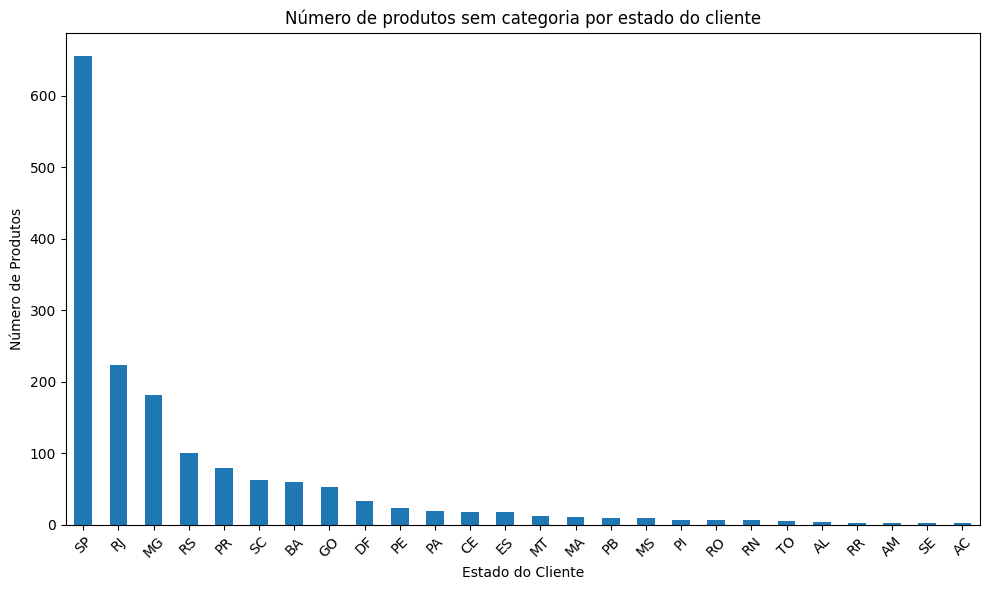

In [101]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
product_cus['customer_state'].value_counts().plot(kind='bar')
plt.title('Número de produtos sem categoria por estado do cliente')
plt.xlabel('Estado do Cliente')
plt.ylabel('Número de Produtos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Top 10 Produtos Mais Vendidos')

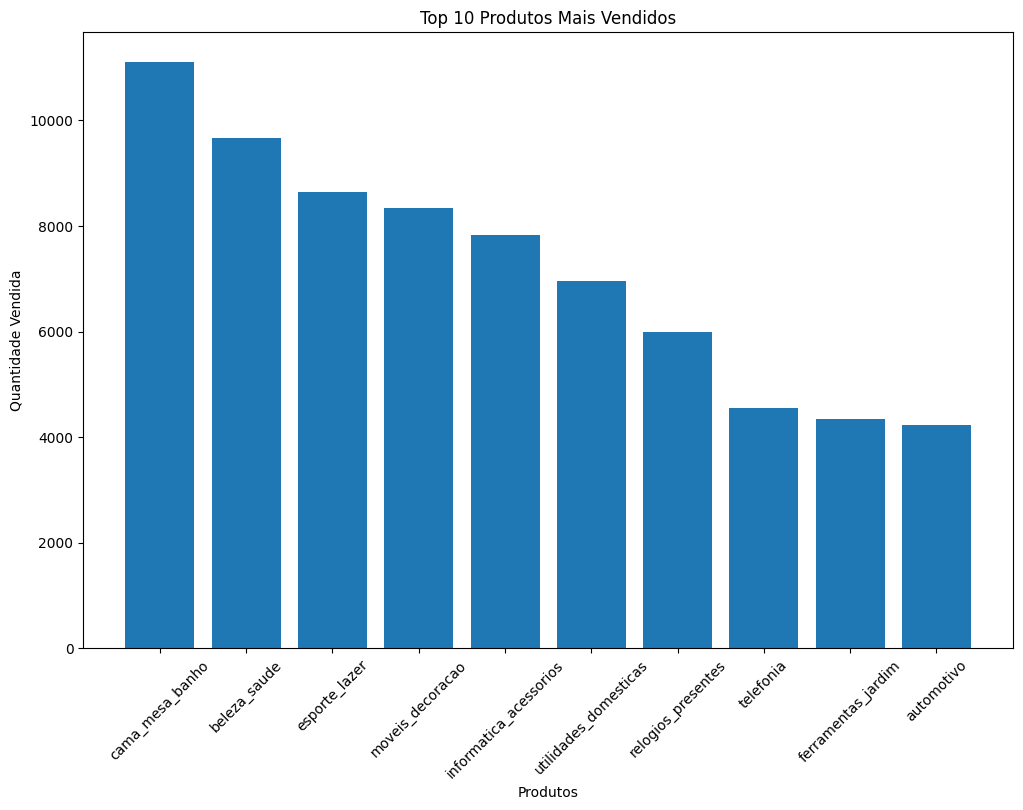

In [120]:
product_not_null = product_item_order.loc[product_item_order['product_category_name'].notnull()]
sell_products = product_not_null.groupby('product_category_name').size()
top10_products = sell_products.sort_values(ascending=False).head(10)
plt.figure(figsize=(12,8))
plt.bar(top10_products.index, top10_products.values)
plt.xticks(rotation=45)
plt.xlabel('Produtos')
plt.ylabel('Quantidade Vendida')
plt.title('Top 10 Produtos Mais Vendidos')